# Lecture 04 — Salary estimator

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Regression · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Estimate monthly salary (OMR) from a deliberately fictional employment dataset.

## Practical problem
A fictional HR analytics class estimates monthly salary and discusses limitations, representativeness and responsible use.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** All salary values are synthetic, not Oman wage observations; use is for teaching only, not employment decisions.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 720 rows × 5 columns


,years_experience,education_years,management_role,skills_score,monthly_salary_omr
0,22.9,16,1,6.2,2483.5
1,2.2,16,0,8.0,1019.2
2,3.6,16,0,5.4,717.0
3,7.3,16,0,8.0,1169.6
4,8.5,16,0,1.9,1305.7


In [8]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['years_experience', 'education_years', 'management_role', 'skills_score', 'monthly_salary_omr']
Missing values per column:
years_experience      0
education_years       0
management_role       0
skills_score          0
monthly_salary_omr    0


## 2. Visualise the target and input–output relationship
For regression the output is **a number**. Study the scatterplot and target distribution before selecting a model.

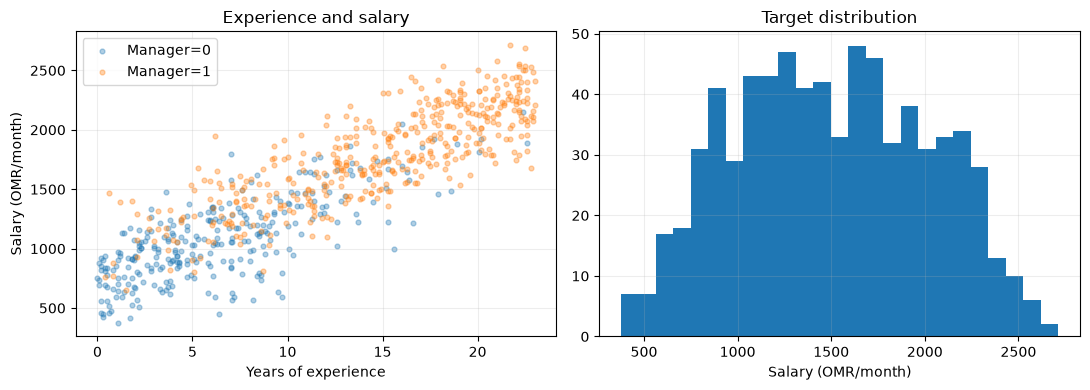

In [9]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for r in [0,1]:
 s=df[df['management_role']==r]
 ax[0].scatter(s['years_experience'],s['monthly_salary_omr'],s=12,alpha=.35,label=f'Manager={r}')
ax[0].legend();ax[0].set(xlabel='Years of experience',ylabel='Salary (OMR/month)',title='Experience and salary')
ax[1].hist(df['monthly_salary_omr'],bins=25);ax[1].set(xlabel='Salary (OMR/month)',title='Target distribution');plt.tight_layout();plt.show()

## 3. Split the data and fit the chosen regression model
Fit on training data only. The test set estimates how predictions may behave on new examples.

In [10]:
from sklearn.model_selection import train_test_split
X=df[['years_experience', 'education_years', 'management_role', 'skills_score']]
y=df['monthly_salary_omr']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)
print('Training rows:',len(X_train),'Test rows:',len(X_test))

Training rows: 540 Test rows: 180


### Algorithm choice
**Multiple linear regression** shows how several numeric features jointly contribute to a numeric salary prediction.

In [11]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print('Coefficients:',dict(zip(X.columns,np.round(model.coef_,2))))

Coefficients: {'years_experience': np.float64(56.81), 'education_years': np.float64(80.36), 'management_role': np.float64(236.84), 'skills_score': np.float64(33.56)}


## 4. Evaluate: MAE, RMSE and R²
**MAE** gives typical absolute error in the target’s units; **RMSE** penalises larger errors; **R²** compares prediction quality against predicting the mean. **Accuracy, precision, recall and a confusion matrix are not defined for continuous regression outputs** unless you introduce artificial categories, which would change the task.

MAE (OMR/month): 111.894
RMSE (OMR/month): 143.175
R²: 0.918


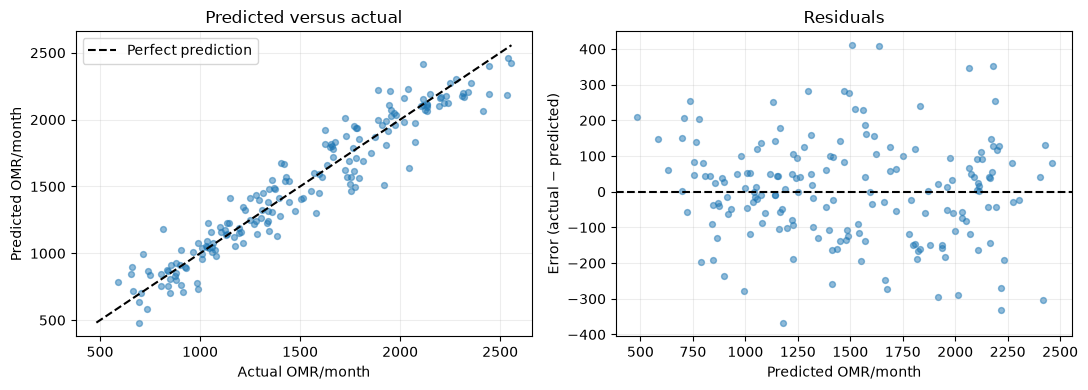

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
pred=model.predict(X_test)
print('MAE (OMR/month):',round(mean_absolute_error(y_test,pred),3))
print('RMSE (OMR/month):',round(np.sqrt(mean_squared_error(y_test,pred)),3))
print('R²:',round(r2_score(y_test,pred),3))
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(y_test,pred,alpha=.5,s=18)
limits=[min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]
ax[0].plot(limits,limits,'k--',label='Perfect prediction');ax[0].legend()
ax[0].set(xlabel='Actual OMR/month',ylabel='Predicted OMR/month',title='Predicted versus actual')
ax[1].scatter(pred,y_test-pred,s=18,alpha=.5);ax[1].axhline(0,color='k',linestyle='--')
ax[1].set(xlabel='Predicted OMR/month',ylabel='Error (actual − predicted)',title='Residuals')
plt.tight_layout();plt.show()

## 5. Use the trained model on new inputs
Predictions are meaningful only within the data-generating range; extreme inputs involve extrapolation and are unreliable.

In [13]:
candidates=pd.DataFrame([{'years_experience':2,'education_years':16,'management_role':0,'skills_score':6},{'years_experience':12,'education_years':18,'management_role':1,'skills_score':8}])
candidates['estimated_monthly_salary_omr']=model.predict(candidates).round(1)
display(candidates)

,years_experience,education_years,management_role,skills_score,estimated_monthly_salary_omr
0,2,16,0,6,924.5
1,12,18,1,8,1957.3


## Student investigation and discussion
1. Is a model trained on fabricated salaries fair for real job offers?
2. Interpret one regression coefficient, holding other features fixed.
3. What would happen if we tested a person with 60 years of experience?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.